# MedGemma 4B Multimodal — Experimentación (Colab)

Carga manual del modelo + processor (**sin `pipeline()`**) para dejar el camino libre a fine-tuning con LoRA más adelante.

**Modelo:** `google/medgemma-4b-it` (basado en Gemma 3, multimodal: imagen + texto).

**Requisitos:**
- Runtime con GPU (Colab: *Entorno de ejecución → Cambiar tipo de entorno → GPU*). Una T4 (16 GB) basta.
- MedGemma es un modelo *gated*: acepta los términos en https://huggingface.co/google/medgemma-4b-it y crea un token en https://huggingface.co/settings/tokens

## 1. Instalar dependencias

In [1]:
!pip install -q -U transformers accelerate timm hf_transfer
#!pip install -q -U peft bitsandbytes

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 61.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 46.1 MB/s eta 0:00:00


## 2. Autenticación en Hugging Face (modelo gated)

Pega tu token cuando lo pida. En Colab también puedes guardarlo en *Secrets* (icono de llave) con el nombre `HF_TOKEN` y se tomará automáticamente.

In [2]:
import os
os.environ["HF_HUB_ENABLE_HF_TRANSFER"] = "1"  # descarga más rápida

try:
    from google.colab import userdata
    token = userdata.get("HF_TOKEN")
except Exception:
    token = None

from huggingface_hub import login
if token:
    login(token=token)
else:
    login()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/constants.py:277: FutureWarning: The `HF_HUB_ENABLE_HF_TRANSFER` environment variable is deprecated as 'hf_transfer' is not used anymore. Please use `HF_XET_HIGH_PERFORMANCE` instead to enable high performance transfer with Xet. Visit https://huggingface.co/docs/huggingface_hub/package_reference/environment_variables#hfxethighperformance for more details.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


## 3. Cargar modelo y processor (sin pipeline)

In [3]:
import torch
from transformers import AutoProcessor, AutoModelForImageTextToText

MODEL_ID = "google/medgemma-4b-it"

# bfloat16 funciona en T4/A100. Si tu GPU diera problemas, prueba torch.float16.
DTYPE = torch.bfloat16

processor = AutoProcessor.from_pretrained(MODEL_ID)

model = AutoModelForImageTextToText.from_pretrained(
    MODEL_ID,
    torch_dtype=DTYPE,
    device_map="auto",
    # 'eager' es lo recomendado para Gemma 3 (estabilidad, sobre todo al entrenar con LoRA).
    attn_implementation="eager",
)
model.eval()

processor_config.json:   0%|          | 0.00/70.0 [00:00<?, ?B/s]

chat_template.jinja:   0%|          | 0.00/1.53k [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/2.47k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/1.16M [00:00<?, ?B/s]

...

model.safetensors.index.json:   0%|          | 0.00/90.6k [00:00<?, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/883 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

Modelo cargado en: cuda:0
Parámetros (M): 4300.1


## 4. Función helper para preguntar sobre una imagen

Construimos los mensajes en formato *chat* y los pasamos por `apply_chat_template`. Esto es exactamente lo que hace `pipeline` por debajo, pero teniéndolo explícito controlamos cada paso (clave para fine-tuning).

In [25]:
from PIL import Image

@torch.inference_mode()
def ask_image(image,
              question,
              system_prompt="You are an expert ophthalmologist.",
              max_new_tokens=300,
              temperature=0.0):

    messages = [
        {"role": "system", "content": [{"type": "text", "text": system_prompt}]},
        {"role": "user", "content": [{"type": "image", "image": image}]
                                  + [{"type": "text", "text": question}]}
    ]

    inputs = processor.apply_chat_template(
        messages,
        add_generation_prompt=True,
        tokenize=True,
        return_dict=True,
        return_tensors="pt",
    ).to(model.device, dtype=DTYPE)

    input_len = inputs["input_ids"].shape[-1]

    do_sample = temperature > 0.0
    gen = model.generate(
        **inputs,
        max_new_tokens=max_new_tokens,
        do_sample=do_sample,
        temperature=temperature if do_sample else None,
    )
    # Recortamos el prompt para quedarnos solo con lo generado.
    out_tokens = gen[0][input_len:]
    return processor.decode(out_tokens, skip_special_tokens=True).strip()

## 5. Cargar una imagen


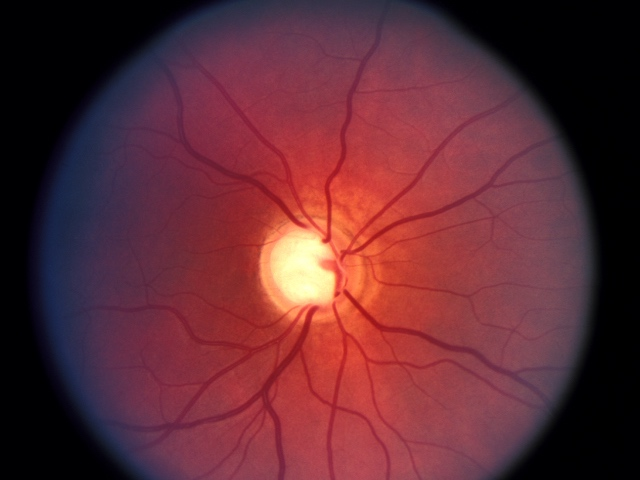

In [23]:
from PIL import Image
import requests

image = Image.open("glaucoma.jpg").convert("RGB")
#url = "https://oftalmyc.com/wp-content/uploads/2020/10/glaucoma.jpg"
#image = Image.open(requests.get(url, stream=True).raw).convert("RGB")

image

In [26]:
respuesta = ask_image(
    image,
    "Describe esta imagen de fondo de ojo y dime si hay señales de glaucoma",
)
print(respuesta)

Okay, based on the image you sent, here's my assessment:

**Description of the Fundus Image:**

The image shows a fundus photograph of the retina.  The optic disc, which is the location where the optic nerve exits the eye, is prominent.  The retinal vessels (arteries and veins) are visible, appearing as red lines.  The overall appearance is relatively normal, but there are some notable features.

**Signs of Glaucoma:**

Based on the image, there are some signs that could be suggestive of glaucoma, but it's important to note that a definitive diagnosis requires a comprehensive eye exam, including measurements of intraocular pressure (IOP), visual field testing, and optic nerve evaluation.

Here's what I see that raises suspicion:

*   **Cupping of the Optic Disc:** The optic disc is the area where the optic nerve enters the eye. In glaucoma, the optic nerve can be damaged, leading to a characteristic cupping of the optic disc. The cup appears as a darker, more circular area within the o

---
### Notas para el siguiente paso (LoRA)
- El modelo está cargado como objeto `model` normal de `transformers`, así que más adelante podrás envolverlo con `peft` (`get_peft_model` + `LoraConfig`) sin que nada del wrapper `pipeline` estorbe.
- Para entrenar conviene cargar en 4-bit (`bitsandbytes`) + LoRA (QLoRA) si la VRAM es limitada.
- Mantén `attn_implementation="eager"` durante el entrenamiento (recomendado para Gemma 3).